# Dinomaly on CBIS-DDSM

Trains the Dinomaly anomaly detector on normal (benign) mammograms and evaluates
malignant detection. Model, loss, and training loop live in `src/`; this notebook
drives a run and shows the loss curve, the per-eval metrics, and the epochs as it
goes.

Train on benign only, score malignant as anomalies. Backbone (DINOv2 ViT-B/14) is
frozen; only the bottleneck + decoder train.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')  # repo root

import numpy as np
import torch
import matplotlib.pyplot as plt

## 1. Device

In [2]:
from src.training.train_dinomaly import pick_device

device = pick_device()
print('device:', device)
print('mps available:', torch.backends.mps.is_available())

device: mps
mps available: True


## 2. Data

Built once here and passed into `train()` so the split is identical across runs.

In [3]:
from src.data.cbis_ddsm import load_datasets

datasets = load_datasets()
{name: len(ds) for name, ds in datasets.items()}

build_image_index: dropping 282 abnormality rows with no matching full-mammogram entry in dicom_info.csv


{'train_normal': 1353, 'test_normal': 227, 'test_anomaly': 1277}

A few images going in (after resize/crop/normalize, undone here for display).

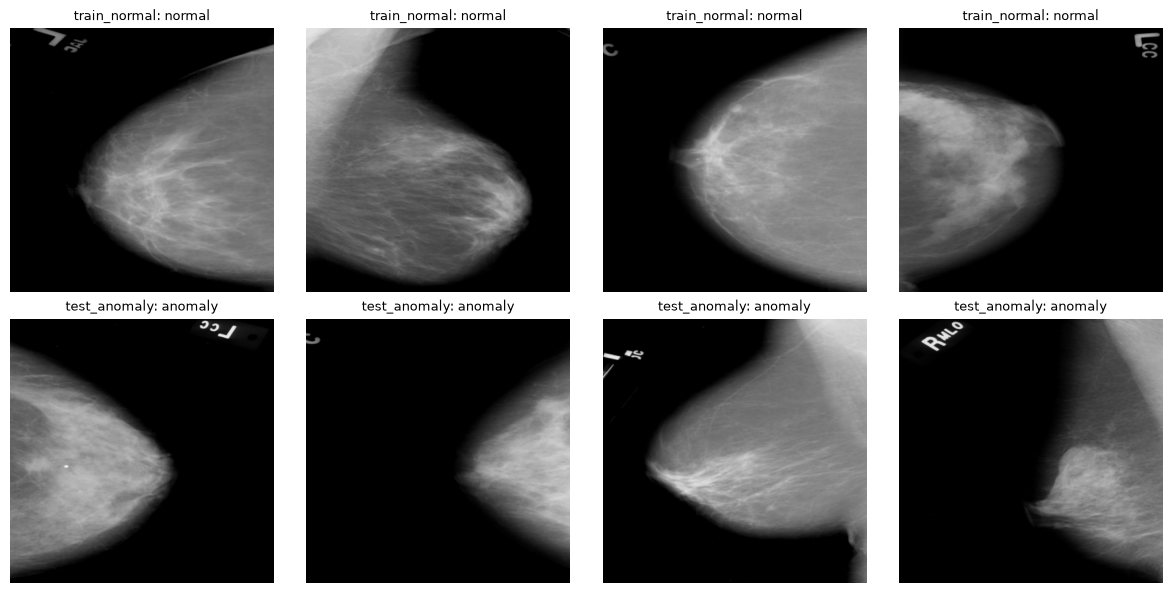

In [4]:
from src.data.cbis_ddsm import IMAGENET_MEAN, IMAGENET_STD

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, split in enumerate(['train_normal', 'test_anomaly']):
    ds = datasets[split]
    for col in range(4):
        img, label = ds[col * (len(ds) // 4)]
        axes[row, col].imshow((img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy())
        axes[row, col].set_title(f'{split}: {label}', fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

## 3. Config

Defaults match Dinomaly's `dinomaly_mvtec_uni.py`. 1353 train images / batch 16 (drop_last) is 84 batches per epoch, so 10k iters is about 119 epochs.

`QUICK_TEST = True` runs ~120 iters to check the whole path end to end. Flip it to `False` for the full run (~3 h on an M4 Max).

In [5]:
from src.training.train_dinomaly import TrainConfig

QUICK_TEST = True

if QUICK_TEST:
    cfg = TrainConfig(backbone='vit_base', iters=120, eval_every=120, warmup_iters=20, hm_ramp_iters=120)
else:
    cfg = TrainConfig(backbone='vit_base', iters=10000, eval_every=2000)

import math
batches_per_epoch = len(datasets['train_normal']) // cfg.batch_size
print(f"{cfg.iters} iters  ~  {math.ceil(cfg.iters / batches_per_epoch)} epochs  ({batches_per_epoch} batches/epoch)")
cfg

120 iters  ~  2 epochs  (84 batches/epoch)


TrainConfig(backbone='vit_base', iters=120, batch_size=16, lr=0.002, final_lr=0.0002, warmup_iters=20, eval_every=120, num_workers=4, seed=1, log_every=50, hm_ramp_iters=120, hm_p=0.9, hm_factor=0.1, grad_clip=0.1, out_dir=None)

## 4. Train

The bar shows iteration, epoch, loss, and LR live. Eval runs every `eval_every` iters (AUROC / AP / F1max on the held-out normal + all malignant), and a checkpoint is written each time. Interrupting the kernel stops the loop with the last checkpoint kept.

In [6]:
from src.training.train_dinomaly import train

history = train(cfg, datasets=datasets, device=device)

/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


device mps | backbone vit_base | trainable 61.4M
train_normal 1353 | test_normal 227 | test_anomaly 1277 | 84 batches/epoch -> 2 epochs
-> /Users/toriav/Desktop/Erem - Honours/mammo-uad-2d3d/runs/dinomaly_20260911_120206


  0%|          | 0/120 [00:00<?, ?it/s]

[eval @ iter 120 / epoch 2]  AUROC 0.5477  AP 0.8667  F1max 0.9184
done in 7.5 min  ->  /Users/toriav/Desktop/Erem - Honours/mammo-uad-2d3d/runs/dinomaly_20260911_120206


## 5. Results

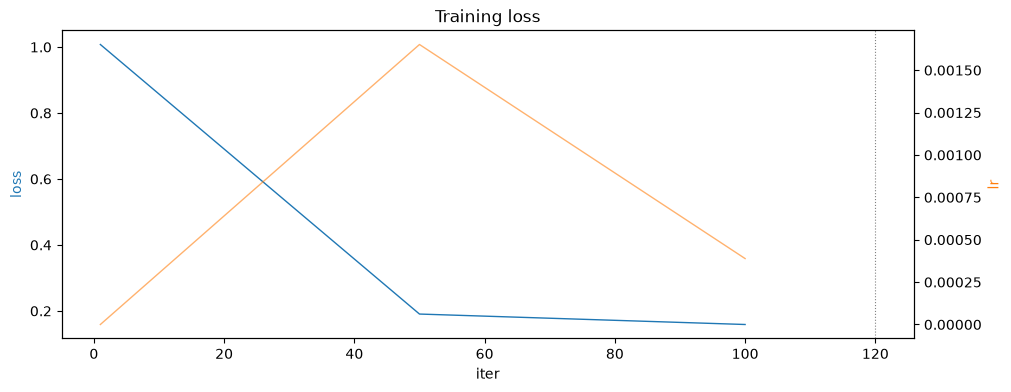

In [7]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(history['iters'], history['loss'], color='tab:blue', lw=1)
ax1.set_xlabel('iter'); ax1.set_ylabel('loss', color='tab:blue')
ax1.set_title('Training loss')

ax2 = ax1.twinx()
ax2.plot(history['iters'], history['lr'], color='tab:orange', lw=1, alpha=0.6)
ax2.set_ylabel('lr', color='tab:orange')

for e in history['evals']:
    ax1.axvline(e['iter'], color='grey', ls=':', lw=0.8)
plt.show()

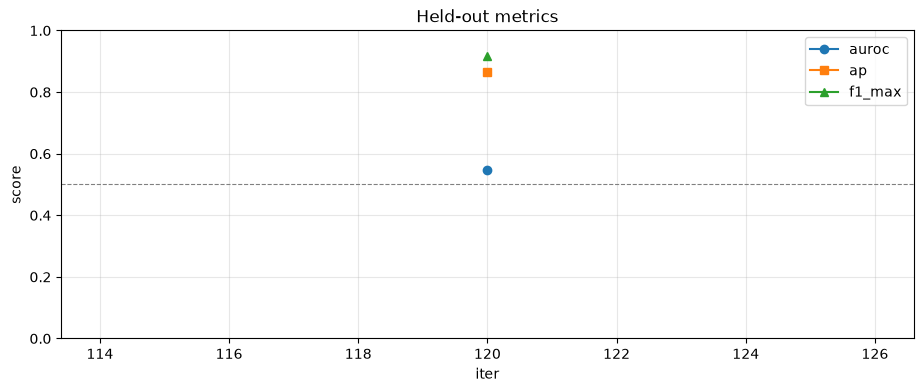

In [8]:
evals = history['evals']
if evals:
    its = [e['iter'] for e in evals]
    fig, ax = plt.subplots(figsize=(11, 4))
    for key, mark in [('auroc', 'o-'), ('ap', 's-'), ('f1_max', '^-')]:
        ax.plot(its, [e[key] for e in evals], mark, label=key)
    ax.set_xlabel('iter'); ax.set_ylabel('score'); ax.set_ylim(0, 1)
    ax.axhline(0.5, color='grey', ls='--', lw=0.8)
    ax.legend(); ax.set_title('Held-out metrics'); ax.grid(alpha=0.3)
    plt.show()

In [9]:
import pandas as pd

df = pd.DataFrame(history['evals'])
print('elapsed: {:.1f} min   checkpoints: {}'.format(history['elapsed_min'], history['out_dir']))
df[['iter', 'epoch', 'auroc', 'ap', 'f1_max']] if len(df) else 'no evals recorded'

elapsed: 7.5 min   checkpoints: /Users/toriav/Desktop/Erem - Honours/mammo-uad-2d3d/runs/dinomaly_20260911_120206


,iter,epoch,auroc,ap,f1_max
0,120,2,0.547696,0.866721,0.918375


## 6. Load a checkpoint

```python
ckpt = torch.load(f"{history['out_dir']}/checkpoint.pt", map_location=device)
model, trainable = build_dinomaly(ckpt['config']['backbone'])
trainable.load_state_dict(ckpt['trainable'])
model = model.to(device).eval()
```

Only the bottleneck + decoder are in the checkpoint; the frozen DINOv2 weights come
from the `torch.hub` cache.